# Book Publishing Sales Analysis
### Exploring how publishers, authors, prices, and ratings shape book sales using Python and Pandas.

## 1. Data Cleaning, Transformation, and Preparation

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',30)
pd.set_option('display.width',120)
pd.set_option('display.max_colwidth',None)

sns.set_style('whitegrid')
%matplotlib inline

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [90]:
df = pd.read_csv('bookPublishingData.csv')

df.shape

(1070, 14)

In [91]:
df.head()

,Publishing_Year,Book_Name,Author,Language_Code,Author_Rating,Book_Average_Rating,Book_Ratings_Count,Genre,Gross_Sales,Publisher_Revenue,Sale_Price,Sale_Rank,Publisher,Units_Sold
0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lewis, Dennis O'Neil",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Publishing_Year      1069 non-null   float64
 1   Book_Name            1047 non-null   object 
 2   Author               1070 non-null   object 
 3   Language_Code        1017 non-null   object 
 4   Author_Rating        1070 non-null   object 
 5   Book_Average_Rating  1070 non-null   float64
 6   Book_Ratings_Count   1070 non-null   int64  
 7   Genre                1070 non-null   object 
 8   Gross_Sales          1070 non-null   float64
 9   Publisher_Revenue    1070 non-null   float64
 10  Sale_Price           1070 non-null   float64
 11  Sale_Rank            1070 non-null   int64  
 12  Publisher            1070 non-null   object 
 13  Units_Sold           1070 non-null   int64  
dtypes: float64(5), int64(3), object(6)
memory usage: 117.2+ KB


In [93]:
df.isna().sum().sort_values(ascending=False)

Language_Code          53
Book_Name              23
Publishing_Year         1
Author                  0
Author_Rating           0
Book_Average_Rating     0
Book_Ratings_Count      0
Genre                   0
Gross_Sales             0
Publisher_Revenue       0
Sale_Price              0
Sale_Rank               0
Publisher               0
Units_Sold              0
dtype: int64

In [94]:
df = df.dropna(subset=["Publishing_Year", "Book_Name"])
df = df.drop(df[df['Publishing_Year'] < 0].index)

df = df.drop_duplicates()

df.head()

,Publishing_Year,Book_Name,Author,Language_Code,Author_Rating,Book_Average_Rating,Book_Ratings_Count,Genre,Gross_Sales,Publisher_Revenue,Sale_Price,Sale_Rank,Publisher,Units_Sold
0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lewis, Dennis O'Neil",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [95]:
df['Publishing_Year'] = df['Publishing_Year'].astype('int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1041 entries, 0 to 1069
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Publishing_Year      1041 non-null   int64  
 1   Book_Name            1041 non-null   object 
 2   Author               1041 non-null   object 
 3   Language_Code        992 non-null    object 
 4   Author_Rating        1041 non-null   object 
 5   Book_Average_Rating  1041 non-null   float64
 6   Book_Ratings_Count   1041 non-null   int64  
 7   Genre                1041 non-null   object 
 8   Gross_Sales          1041 non-null   float64
 9   Publisher_Revenue    1041 non-null   float64
 10  Sale_Price           1041 non-null   float64
 11  Sale_Rank            1041 non-null   int64  
 12  Publisher            1041 non-null   object 
 13  Units_Sold           1041 non-null   int64  
dtypes: float64(4), int64(4), object(6)
memory usage: 122.0+ KB


In [96]:
df.describe()

,Publishing_Year,Book_Average_Rating,Book_Ratings_Count,Gross_Sales,Publisher_Revenue,Sale_Price,Sale_Rank,Units_Sold
count,1041.000000,1041.000000,1041.000000,1041.000000,1041.000000,1041.000000,1041.000000,1041.000000
mean,1984.520653,4.003199,95054.141210,1853.605139,836.631055,4.849664,610.123919,9769.004803
std,59.310994,0.246688,31463.001018,3950.028753,2261.459266,3.571715,369.418690,15448.827162
min,1308.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,1985.000000,3.850000,70446.000000,357.540000,0.000000,1.990000,287.000000,555.000000
50%,2003.000000,4.010000,89460.000000,803.850000,266.112000,3.990000,594.000000,3942.000000
75%,2010.000000,4.170000,113977.000000,1488.270000,720.060000,6.990000,924.000000,5373.000000
max,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [97]:
df['Book_ID'] = df.index

df.head()

,Publishing_Year,Book_Name,Author,Language_Code,Author_Rating,Book_Average_Rating,Book_Ratings_Count,Genre,Gross_Sales,Publisher_Revenue,Sale_Price,Sale_Rank,Publisher,Units_Sold,Book_ID
0,1975,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000,0
1,1987,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lewis, Dennis O'Neil",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250,1
2,2015,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500,2
3,2008,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500,3
4,2011,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750,4


In [98]:
#Create Author_List to df (temporary)
df['Author_List'] = (
    df['Author']
    .astype(str)
    .str.split(',')
    .apply(lambda lst: [a.strip() for a in lst])
)

#Build df_authors from the exploded list
df_authors = (
    df[['Book_ID', 'Author_List']]
    .explode('Author_List')
    .rename(columns={'Author_List': 'Author'})
)

num_authors = df_authors.groupby('Book_ID').size()
df['Num_Authors'] = df['Book_ID'].map(num_authors)

#Remove Author_List from df
df = df.drop(columns=['Author_List'])

In [99]:
df.head()

,Publishing_Year,Book_Name,Author,Language_Code,Author_Rating,Book_Average_Rating,Book_Ratings_Count,Genre,Gross_Sales,Publisher_Revenue,Sale_Price,Sale_Rank,Publisher,Units_Sold,Book_ID,Num_Authors
0,1975,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000,0,2
1,1987,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lewis, Dennis O'Neil",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250,1,4
2,2015,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500,2,1
3,2008,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500,3,1
4,2011,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750,4,1


In [100]:
df_authors.head(10)

,Book_ID,Author
0,0,Unknown
0,0,Seamus Heaney
1,1,Frank Miller
1,1,David Mazzucchelli
1,1,Richmond Lewis
1,1,Dennis O'Neil
2,2,Harper Lee
3,3,David Sedaris
4,4,Laini Taylor
5,5,Victoria Aveyard


In [101]:
df_authors.shape

(1369, 2)

## 2. Exploratory Data Analysis (EDA)

### 2.1 Univariate Analysis

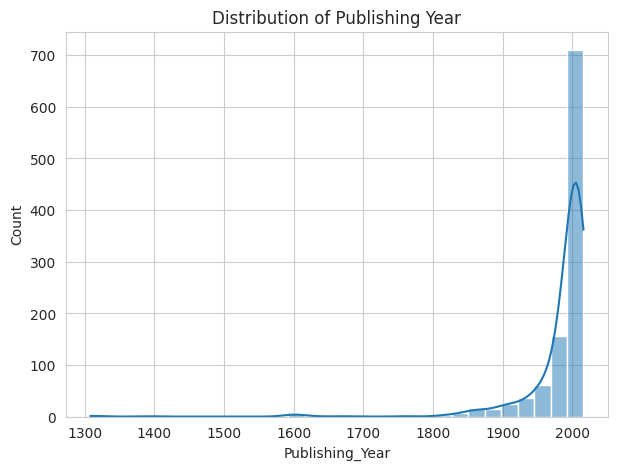

In [102]:
# Publishing year distribution
plt.figure(figsize=(7,5))
sns.histplot(df['Publishing_Year'], bins=30, kde=True)
plt.title('Distribution of Publishing Year')
plt.show()

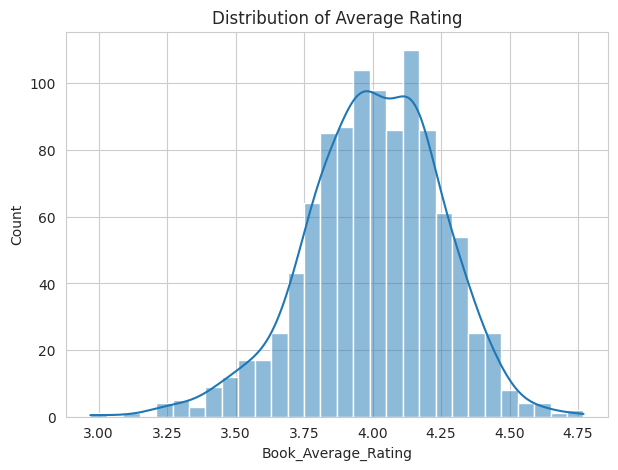

In [103]:
# Average rating distribution
plt.figure(figsize=(7,5))
sns.histplot(df['Book_Average_Rating'], bins=30, kde=True)
plt.title('Distribution of Average Rating')
plt.show()

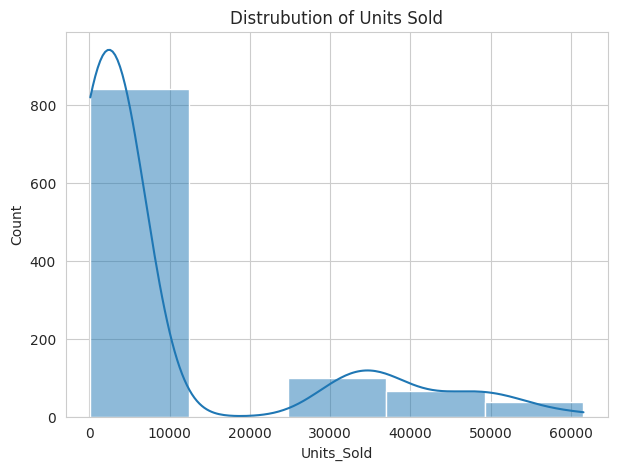

In [104]:
# Units sold overview
plt.figure(figsize=(7,5))
sns.histplot(df['Units_Sold'], bins=5, kde=True)
plt.title('Distrubution of Units Sold')
plt.show()

### 2.2 Categorical Variable Analysis

In [105]:
df['Publisher'].value_counts()

Publisher
Amazon Digital Services,  Inc.          587
Random House LLC                        119
Penguin Group (USA) LLC                 100
HarperCollins Publishers                 68
Hachette Book Group                      62
Simon and Schuster Digital Sales Inc     56
Macmillan                                41
HarperCollins Publishing                  4
HarperCollins Christian Publishing        4
Name: count, dtype: int64

In [106]:
df['Genre'].value_counts()

Genre
genre fiction    799
nonfiction       168
fiction           59
children          15
Name: count, dtype: int64

In [107]:
df['Author_Rating'].value_counts()

Author_Rating
Intermediate    614
Excellent       348
Famous           49
Novice           30
Name: count, dtype: int64

### 2.3 Bivariate Relationships

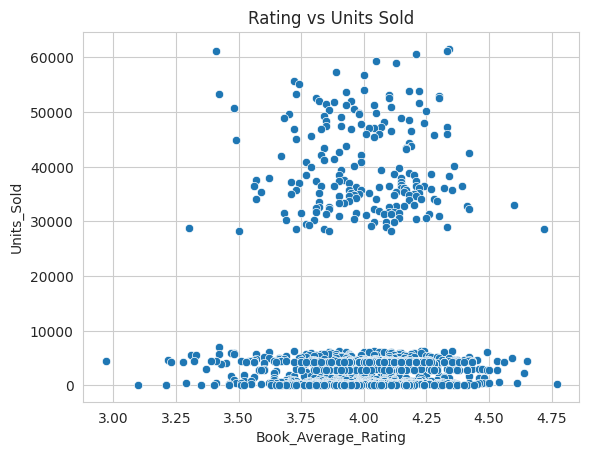

In [108]:
# Ratings vs sales
sns.scatterplot(data=df, x='Book_Average_Rating', y='Units_Sold')
plt.title("Rating vs Units Sold")
plt.show()

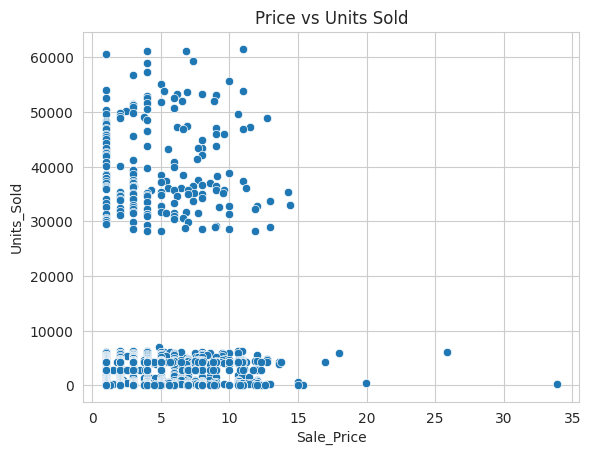

In [109]:
# Price vs sales
sns.scatterplot(data=df, x='Sale_Price', y='Units_Sold')
plt.title("Price vs Units Sold")
plt.show()

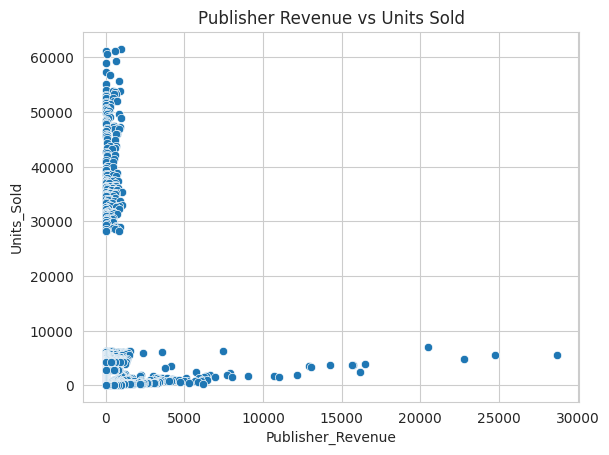

In [110]:
# Revenue vs sales
sns.scatterplot(data=df, x='Publisher_Revenue', y='Units_Sold')
plt.title("Publisher Revenue vs Units Sold")
plt.show()

### 2.4 Multivariate Analysis

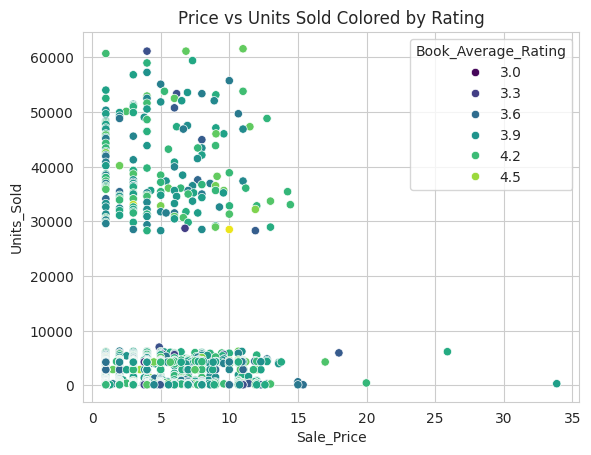

In [111]:
# Price–rating–sales interaction

sns.scatterplot(
    data=df,
    x='Sale_Price',
    y='Units_Sold',
    hue='Book_Average_Rating',
    palette='viridis'
)
plt.title("Price vs Units Sold Colored by Rating")
plt.show()

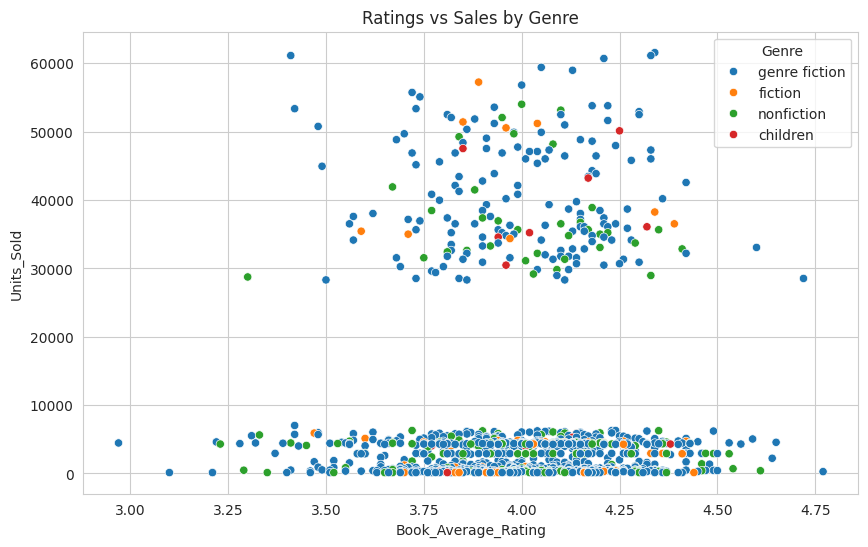

In [112]:
# Genre–rating–sales pattern

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Book_Average_Rating',
    y='Units_Sold',
    hue='Genre'
)
plt.title("Ratings vs Sales by Genre")
plt.show()

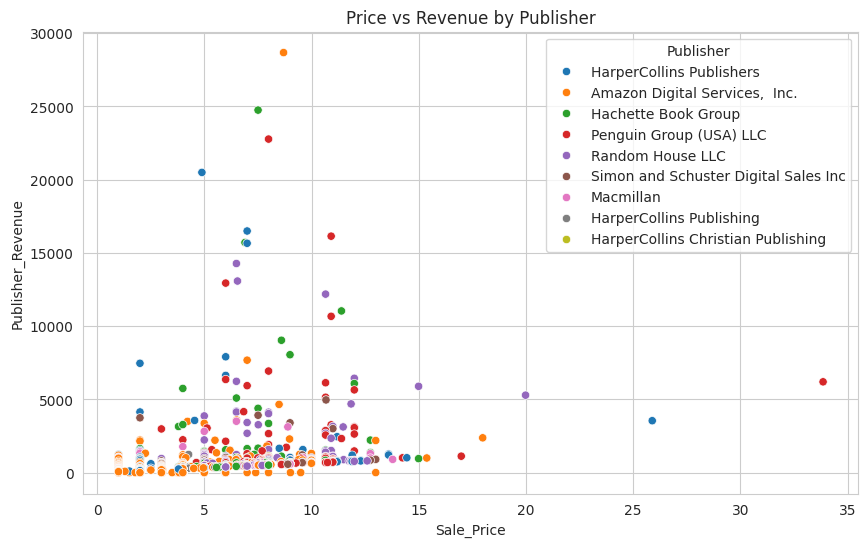

In [113]:
# Publisher price–revenue pattern

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Sale_Price',
    y='Publisher_Revenue',
    hue='Publisher'
)
plt.title("Price vs Revenue by Publisher")
plt.show()

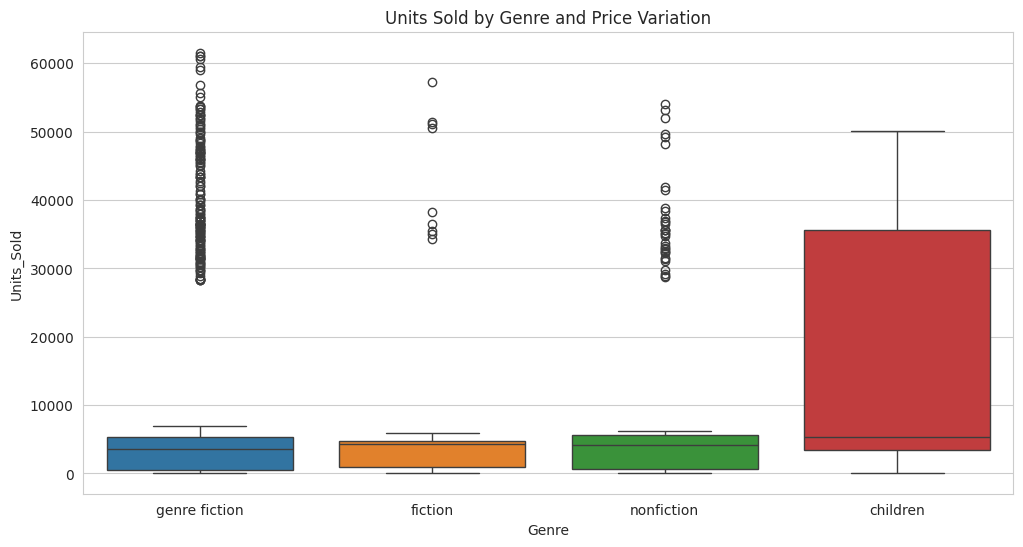

In [114]:
# Genre sales comparison

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Genre', y='Units_Sold', hue='Genre')
plt.title("Units Sold by Genre and Price Variation")
plt.show()

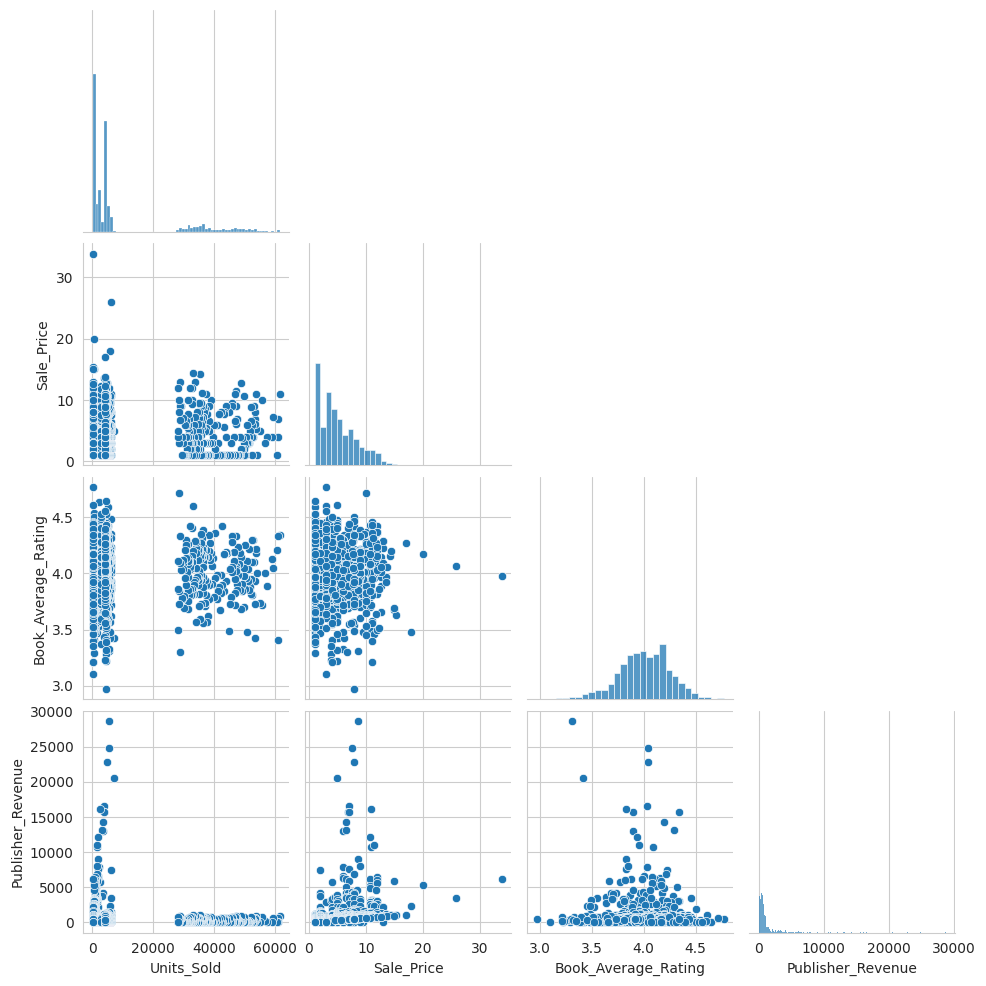

In [115]:
# Pairplot: quick visual overview

sns.pairplot(
    df[['Units_Sold', 'Sale_Price', 'Book_Average_Rating', 'Publisher_Revenue']],
    corner=True
)
plt.show()

### 2.5 Correlation Analysis

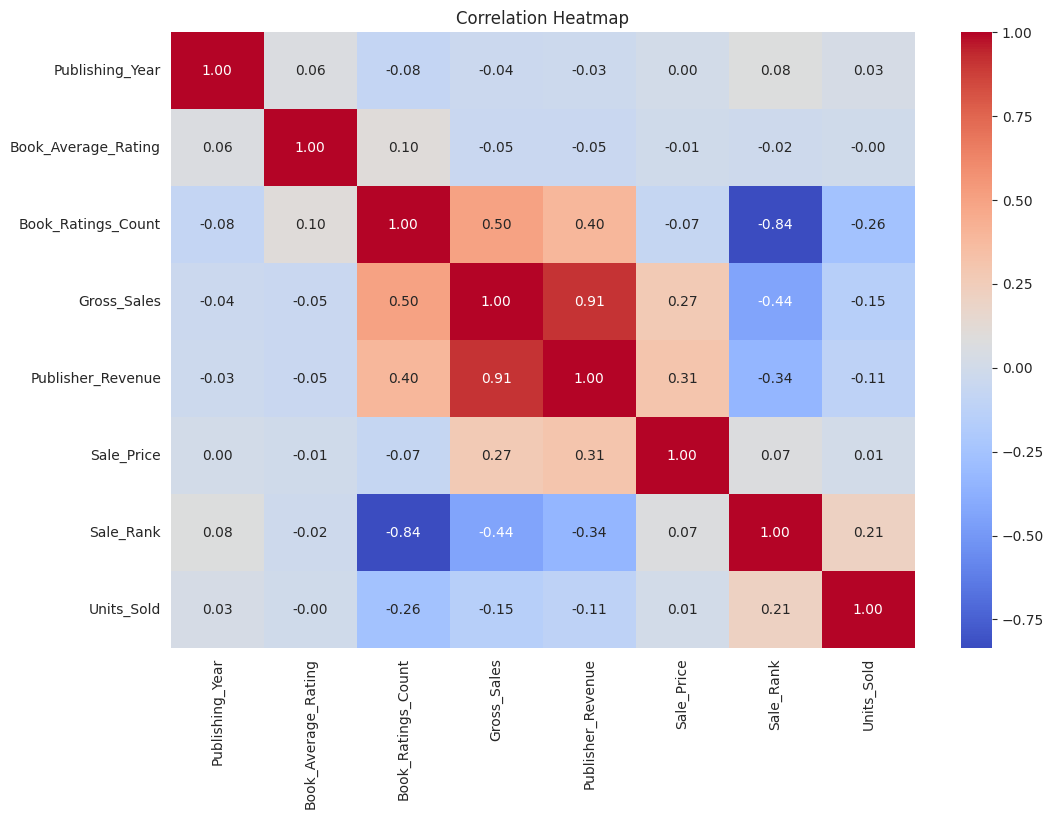

In [116]:
# Numeric correlation heatmap
numeric_cols = df.select_dtypes(include='number').drop(columns=['Book_ID', 'Num_Authors'])
corr = numeric_cols.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

### 2.5 Author-Level Analysis

In [117]:
df_authors['Author'].value_counts().head(10)

Author
Stephen King         42
John Grisham         13
Nicholas Sparks      10
Janet Evanovich      10
Charlaine Harris     10
Jim Butcher          10
Jodi Picoult         10
Brandon Sanderson     9
Robert Jordan         9
Brett Helquist        8
Name: count, dtype: int64

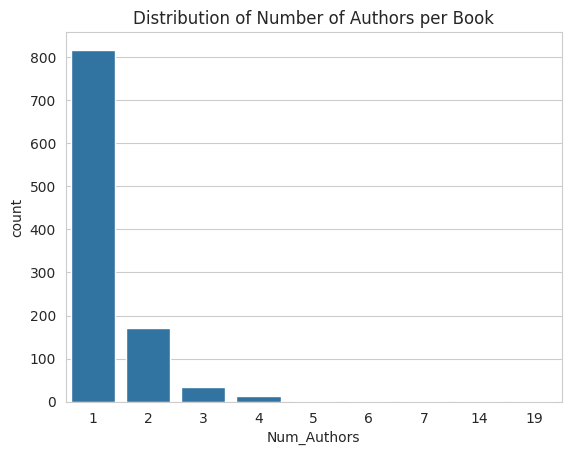

In [118]:
sns.countplot(data=df, x='Num_Authors')
plt.title("Distribution of Number of Authors per Book")
plt.show()

## 3. Insights From EDA

### 3.1 Sales Analysis

In [119]:
# Top 10 bestsellers

top_selling_books = df.sort_values(by='Units_Sold', ascending=False)[
    ['Book_ID', 'Book_Name', 'Units_Sold', 'Publisher', 'Sale_Price']
].head(10)

top_selling_books

,Book_ID,Book_Name,Units_Sold,Publisher,Sale_Price
578,578,New Moon: The Complete Illustrated Movie Companion,61560,Penguin Group (USA) LLC,10.99
579,579,Maybe Someday,61128,Random House LLC,6.83
580,580,Mr Maybe,61128,"Amazon Digital Services, Inc.",3.99
581,581,Anne of the Island,60696,Random House LLC,0.99
582,582,Also sprach Zarathustra,59400,Penguin Group (USA) LLC,7.31
583,583,North and South,58968,"Amazon Digital Services, Inc.",3.99
584,584,A Stolen Life,57240,"Amazon Digital Services, Inc.",3.99
585,585,The Immortals of Meluha,56808,"Amazon Digital Services, Inc.",2.99
586,586,The Lost World,55728,"Amazon Digital Services, Inc.",9.99
587,587,Requiem,55080,"Amazon Digital Services, Inc.",4.99


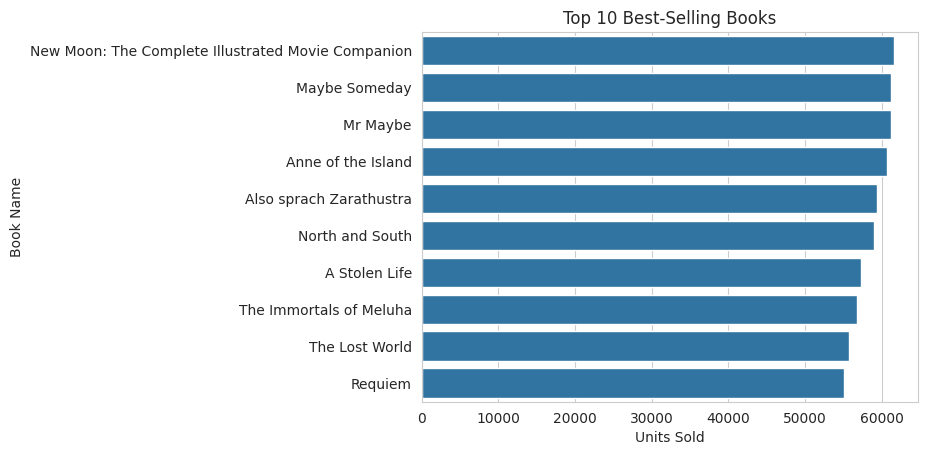

In [120]:
# Bestseller bar chart
sns.barplot(data=top_selling_books, x ='Units_Sold', y='Book_Name')
plt.title("Top 10 Best-Selling Books")
plt.xlabel("Units Sold")
plt.ylabel("Book Name")
plt.show()

In [121]:
publisher_rev = df.groupby('Publisher')['Publisher_Revenue'].sum().sort_values(ascending=False)
publisher_rev.head(10)

Publisher
Penguin Group (USA) LLC                 201498.264
Random House LLC                        178797.222
Amazon Digital Services,  Inc.          145300.194
Hachette Book Group                     135042.882
HarperCollins Publishers                125983.302
Simon and Schuster Digital Sales Inc     46988.352
Macmillan                                32356.236
HarperCollins Publishing                  2830.806
HarperCollins Christian Publishing        2135.670
Name: Publisher_Revenue, dtype: float64

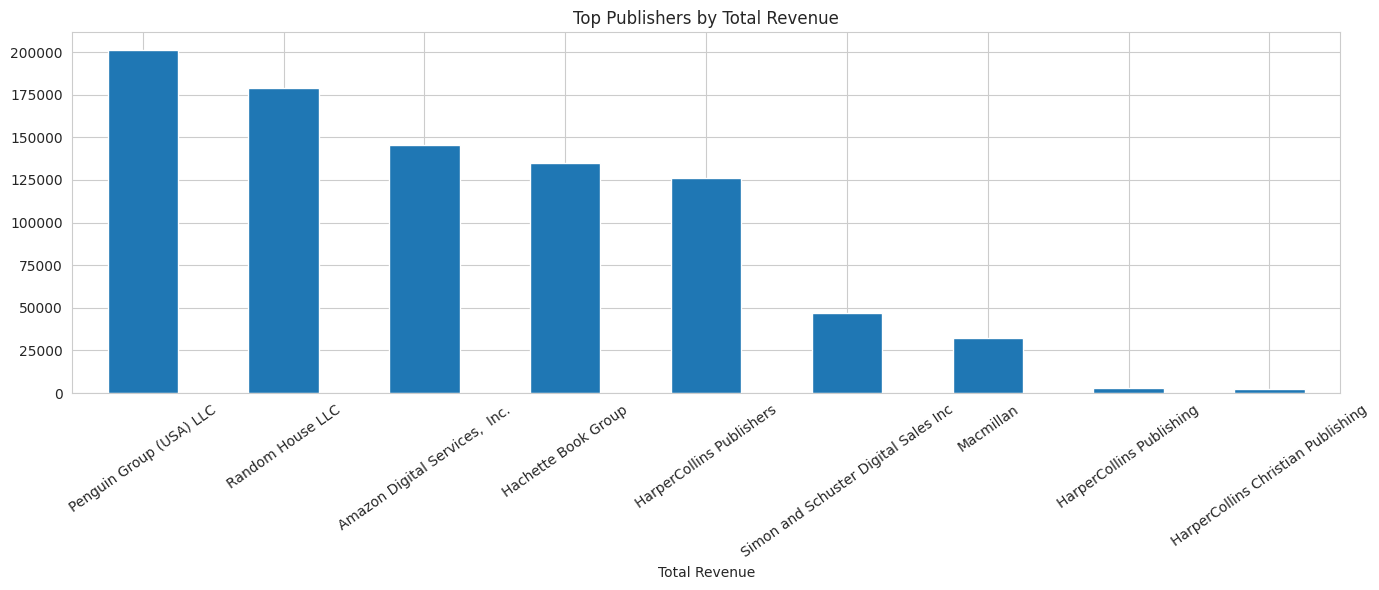

In [122]:
# Top publishers revenue

publisher_rev.head(10).plot(kind='bar', figsize=(14,6))
plt.title("Top Publishers by Total Revenue")
plt.xlabel("Total Revenue")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

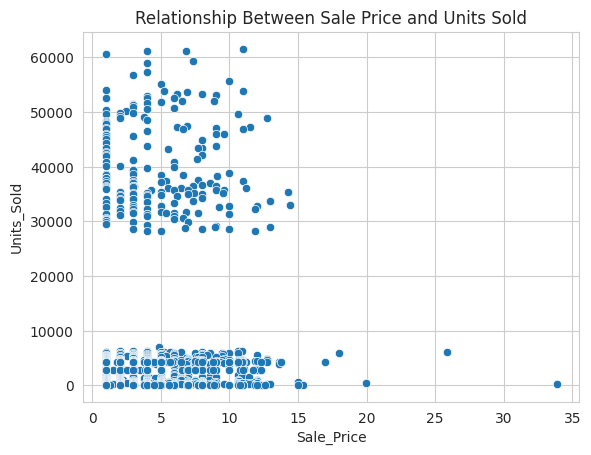

In [123]:
# Price–sales relationship
sns.scatterplot(
    data=df,
    x='Sale_Price',
    y='Units_Sold'
)
plt.title("Relationship Between Sale Price and Units Sold")
plt.show()

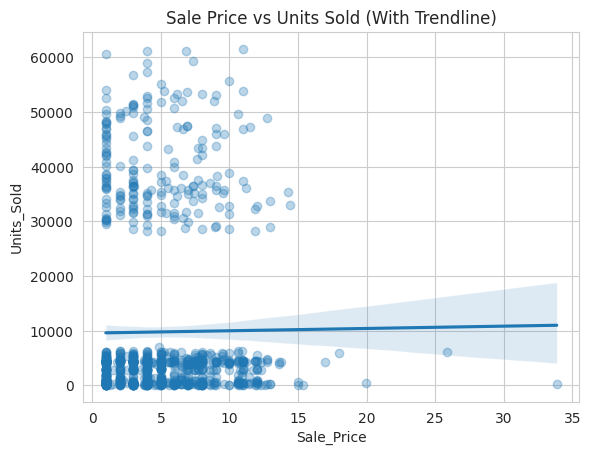

In [124]:
# Price–sales trendline
sns.regplot(
    data=df,
    x='Sale_Price',
    y='Units_Sold',
    scatter_kws={'alpha':0.3}
)
plt.title("Sale Price vs Units Sold (With Trendline)")
plt.show()

### 3.2 RATINGS ANALYSIS

In [125]:
df[['Book_Average_Rating', 'Units_Sold']].corr()

,Book_Average_Rating,Units_Sold
Book_Average_Rating,1.000000,-0.004454
Units_Sold,-0.004454,1.000000


In [126]:
avg_rating_by_genre = df.groupby('Genre')['Book_Average_Rating'].mean().sort_values(ascending=False)
avg_rating_by_genre

Genre
fiction          4.037458
children         4.033333
nonfiction       4.017560
genre fiction    3.997084
Name: Book_Average_Rating, dtype: float64

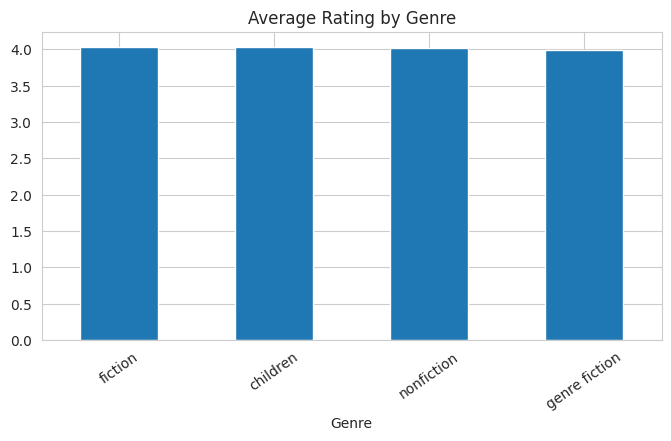

In [127]:
avg_rating_by_genre.plot(kind='bar',figsize=(8,4))
plt.title('Average Rating by Genre')
plt.xticks(rotation=35)
plt.show()

### 3.3 GENRE INSIGHTS

In [128]:
genre_sales = df.groupby('Genre')['Units_Sold'].sum().sort_values(ascending=False)
genre_sales

Genre
genre fiction    7713893
nonfiction       1623609
fiction           533914
children          298118
Name: Units_Sold, dtype: int64

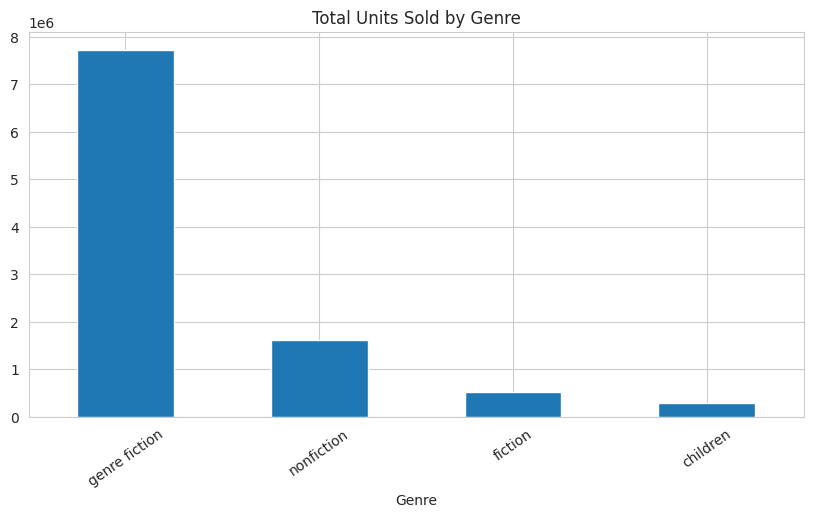

In [129]:
# Genre sales comparison

genre_sales.plot(kind='bar', figsize=(10,5))
plt.title("Total Units Sold by Genre")
plt.xticks(rotation=35)
plt.show()

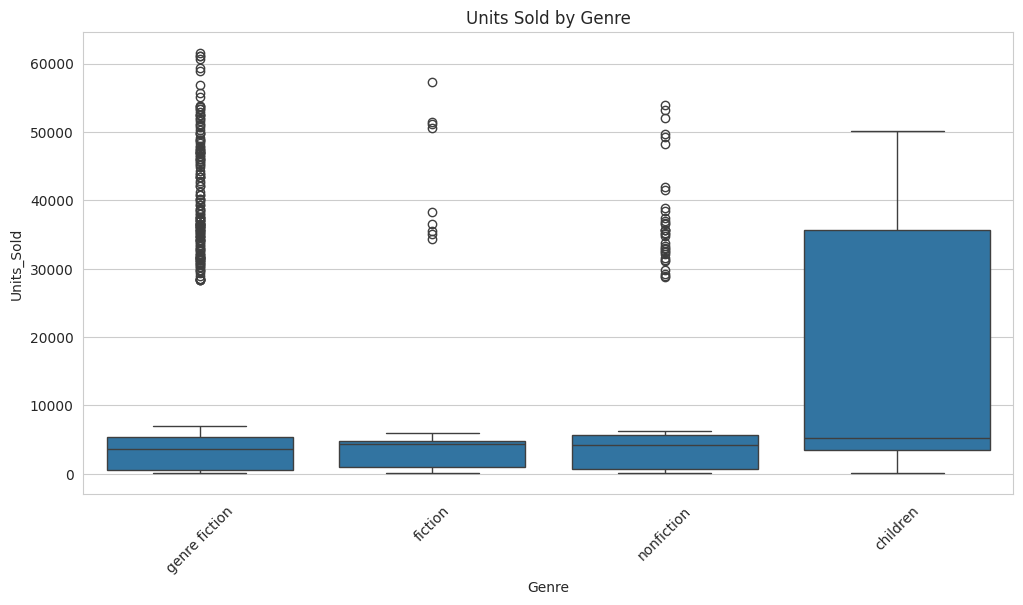

In [130]:
# Genre sales distribution

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Genre', y='Units_Sold')
plt.xticks(rotation=45)
plt.title("Units Sold by Genre")
plt.show()

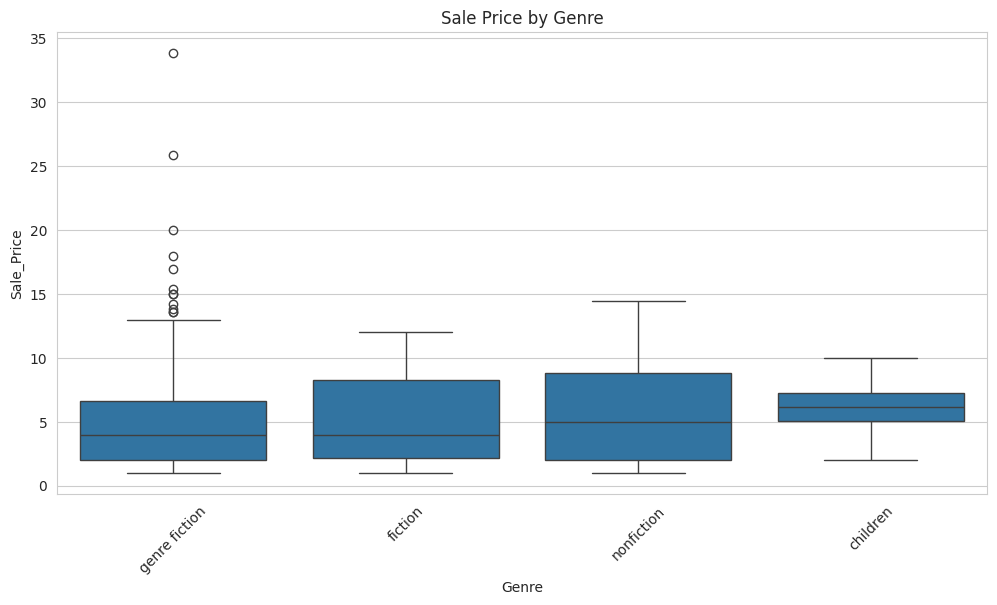

In [131]:
# Genre price distribution

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Genre', y='Sale_Price')
plt.xticks(rotation=45)
plt.title("Sale Price by Genre")
plt.show()

### 3.4 PUBLISHER PERFORMANCE

In [132]:
publisher_revenue = df.groupby('Publisher')['Publisher_Revenue'].sum().sort_values(ascending=False)
publisher_revenue.head(10)

Publisher
Penguin Group (USA) LLC                 201498.264
Random House LLC                        178797.222
Amazon Digital Services,  Inc.          145300.194
Hachette Book Group                     135042.882
HarperCollins Publishers                125983.302
Simon and Schuster Digital Sales Inc     46988.352
Macmillan                                32356.236
HarperCollins Publishing                  2830.806
HarperCollins Christian Publishing        2135.670
Name: Publisher_Revenue, dtype: float64

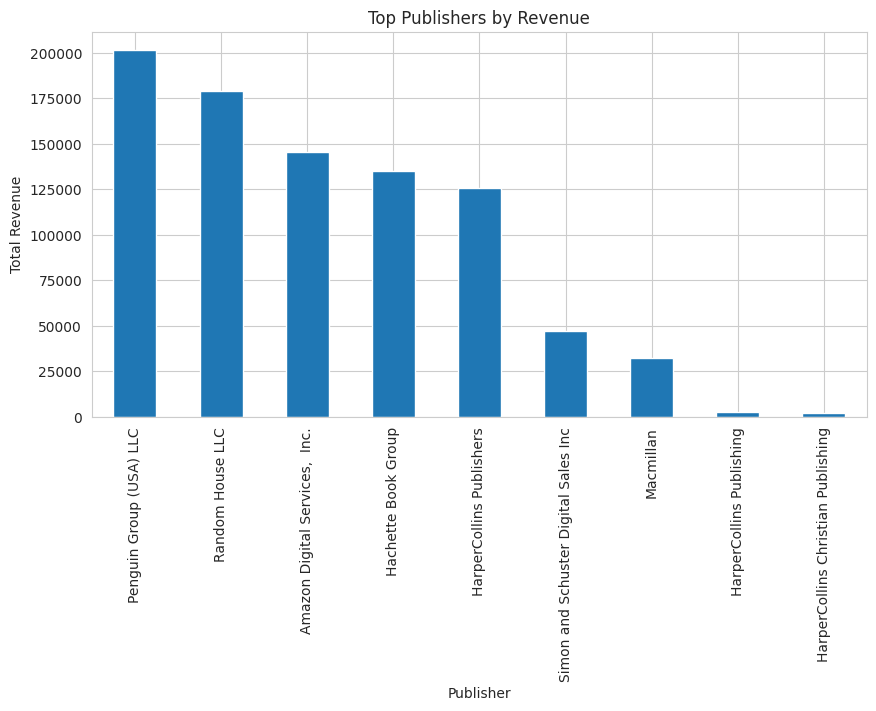

In [133]:
# Publisher revenue ranking

publisher_revenue.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Publishers by Revenue")
plt.ylabel("Total Revenue")
plt.show()

In [134]:
publisher_output = df['Publisher'].value_counts().head(10)
publisher_output

Publisher
Amazon Digital Services,  Inc.          587
Random House LLC                        119
Penguin Group (USA) LLC                 100
HarperCollins Publishers                 68
Hachette Book Group                      62
Simon and Schuster Digital Sales Inc     56
Macmillan                                41
HarperCollins Publishing                  4
HarperCollins Christian Publishing        4
Name: count, dtype: int64

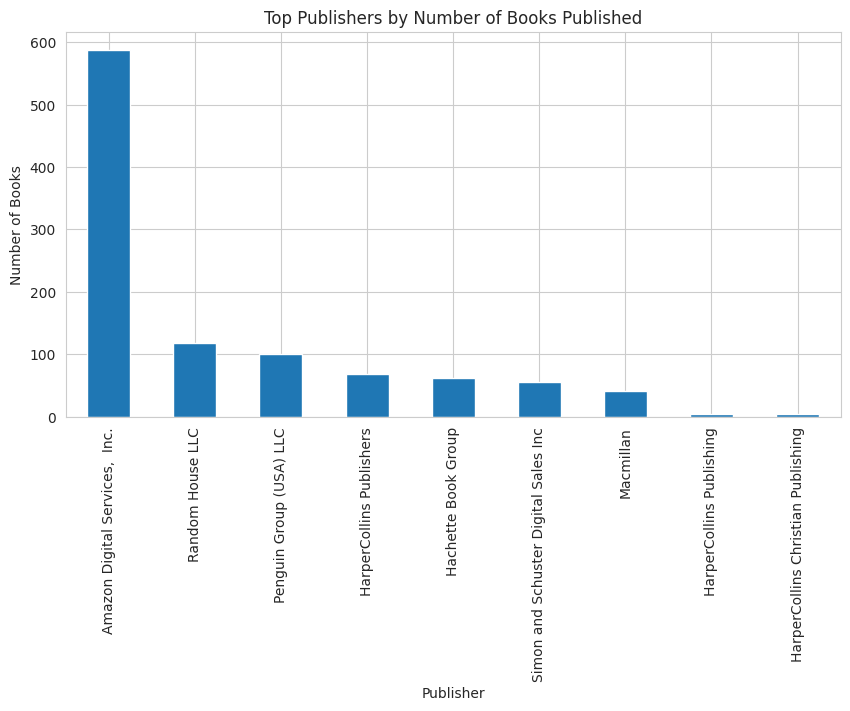

In [135]:
# Publisher output ranking

publisher_output.plot(kind='bar', figsize=(10,5))
plt.title("Top Publishers by Number of Books Published")
plt.ylabel("Number of Books")
plt.show()

## **Conclusion**

Overall, the EDA gave a clear picture of how different factors shape a book’s performance. A **small number of books and publishers drive most of the sales**, while the majority perform more modestly. Ratings do seem to help, but they’re only part of the story—**price** and **genre** also play meaningful roles. Genres vary widely in both how well they sell and how they’re priced, and looking at multiple variables together shows that **these factors often work in combination rather than alone**.
In short, the analysis highlights the **main forces behind book sales** and sets the stage for deeper exploration or modeling in the next steps.